<a href="https://colab.research.google.com/github/Animesh90-me/Dehydration-Prediction/blob/main/notebooks/dehydration_prediction_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import files
files.download("practice_dehydration_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [6]:
import pandas as pd
import numpy as np

file_path = "/content/practice_dehydration_dataset.csv"

df = pd.read_csv(file_path)

print(df.head())
print(df.columns)
print(df.shape)

   time_min  strain_percent  relative_resistance_peak  dehydration_percent
0   374.540              40                    48.645                6.603
1   950.714              30                    70.872               18.235
2   731.994              70                    91.867               13.622
3   598.658              80                    97.286               10.850
4   156.019              40                    44.244                3.520
Index(['time_min', 'strain_percent', 'relative_resistance_peak',
       'dehydration_percent'],
      dtype='object')
(300, 4)


In [7]:
X = df[["time_min", "strain_percent", "relative_resistance_peak"]].values
y = df["dehydration_percent"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 3)
y shape: (300,)


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor

In [10]:
import pandas as pd

file_path = "/content/practice_dehydration_dataset.csv"

df = pd.read_csv(file_path)

df.head()

,time_min,strain_percent,relative_resistance_peak,dehydration_percent
0,374.540,40,48.645,6.603
1,950.714,30,70.872,18.235
2,731.994,70,91.867,13.622
3,598.658,80,97.286,10.850
4,156.019,40,44.244,3.520


In [11]:
X = df[["time_min", "strain_percent", "relative_resistance_peak"]].values
y = df["dehydration_percent"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (300, 3)
y shape: (300,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [15]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [17]:
model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=300, random_state=42)

In [18]:
y_pred = model.predict(X_test_scaled)

In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))

MAE: 0.937
RMSE: 1.224
R²: 0.954


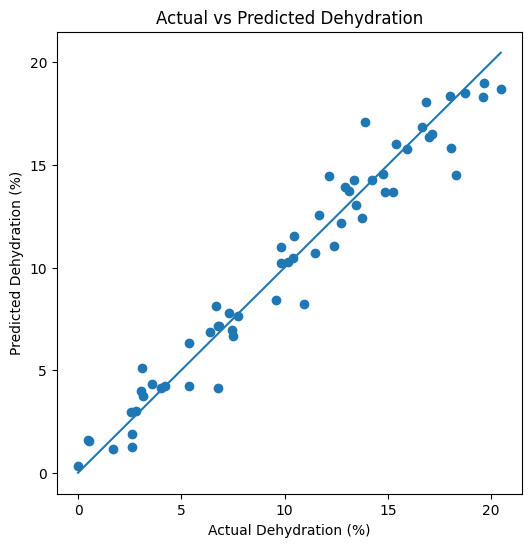

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Dehydration (%)")
plt.ylabel("Predicted Dehydration (%)")
plt.title("Actual vs Predicted Dehydration")

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

In [23]:
time = 1000
strain = 50
relative_resistance_peak = 95

In [24]:
new_sample = np.array([[1000, 50, 95]])

new_sample_scaled = scaler.transform(new_sample)

predicted_dehydration = model.predict(new_sample_scaled)

print("Predicted dehydration (%):", round(predicted_dehydration[0], 2))

Predicted dehydration (%): 19.17
